# 04 - Paper-Faithful Models

Layer 2: the test statistics built directly against the paper's verified formulas -- distance-to-expected-signature, the conformance score, and the Theorem 2.6 CVaR-OCSVM -- plus Weibull-tail and Benjamini-Hochberg-corrected p-values, mirroring the paper's own Section 4.1 methodology.

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

cfg = yaml.safe_load(open('../configs/horizons.yaml'))
periods = cfg['reference_periods']

from src.features.pipeline import (
    HorizonConfig, raw_paths_for_horizon, raw_paths_by_reference_period, fit_reference_scale_multi,
)
from src.paths.transforms import normalize, add_basepoint
from src.ingestion.yahoo import load_daily

macro_cfg = HorizonConfig.from_dict('macro', cfg['horizons']['macro'])
daily = load_daily(cfg['yahoo_ticker'])
if daily.index.tz is None:
    daily.index = daily.index.tz_localize('UTC')

scale = fit_reference_scale_multi(daily, macro_cfg, periods)

# Per-period train/calibration split (~40% of each period's own windows for
# training, the rest held out for calibration) -- same recipe as notebook 05.
raw_by_period = raw_paths_by_reference_period(daily, macro_cfg, periods)
train_frac = 0.4
train_raw, calib_raw = [], []
for period_raw in raw_by_period:
    cut = max(1, round(len(period_raw) * train_frac))
    train_raw.extend(period_raw[:cut])
    calib_raw.extend(period_raw[cut:])

def prep(paths):
    return [add_basepoint(normalize(p, scale)) for p in paths]

train_paths = prep(train_raw)
calib_paths = prep(calib_raw)
ref_paths = train_paths + calib_paths

all_end_times, all_raw = raw_paths_for_horizon(daily, macro_cfg)
all_paths = prep(all_raw)
print(f'{len(raw_by_period)} reference periods -> {len(train_paths)} train, '
      f'{len(calib_paths)} calibration, {len(ref_paths)} total; {len(all_paths)} scored windows')

13 reference periods -> 52 train, 80 calibration, 132 total; 434 scored windows


## Distance-to-expected-signature and conformance score

In [2]:
from src.models.expected_signature import ExpectedSignatureDistance
from src.models.conformance import ConformanceScore

esd_model = ExpectedSignatureDistance(depth=macro_cfg.depth).fit(train_paths)
conf_model = ConformanceScore(depth=macro_cfg.depth).fit(train_paths)

esd_scores = pd.Series(esd_model.score_many(all_paths), index=pd.DatetimeIndex(all_end_times))
conf_scores = pd.Series(conf_model.score_many(all_paths), index=pd.DatetimeIndex(all_end_times))

esd_calib = esd_model.score_many(calib_paths)
conf_calib = conf_model.score_many(calib_paths)

## Weibull tail fit and Benjamini-Hochberg FDR-corrected p-values

Weibull fit: A=0.6321, B=0.0613
BH q=0.10: 90 / 434 windows flagged, p-threshold=0.01235


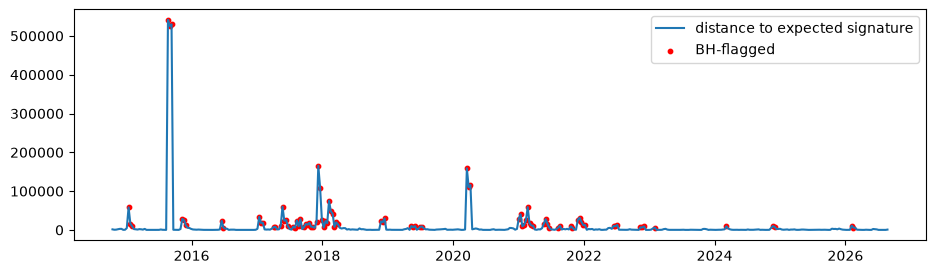

In [3]:
from src.models.tail_bounds import empirical_pvalues, fit_weibull_tail, benjamini_hochberg

A, B = fit_weibull_tail(esd_calib, N=macro_cfg.depth)
print(f'Weibull fit: A={A:.4f}, B={B:.4f}')

p_emp = empirical_pvalues(esd_scores.to_numpy(), esd_calib)
rejections, p_threshold = benjamini_hochberg(p_emp, q=0.10)
print(f'BH q=0.10: {rejections.sum()} / {len(rejections)} windows flagged, p-threshold={p_threshold:.5f}')

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(esd_scores.index, esd_scores.values, label='distance to expected signature')
ax.scatter(esd_scores.index[rejections], esd_scores.values[rejections], color='red', s=10, label='BH-flagged')
ax.legend()
plt.savefig('../reports/expected_signature_bh_flags.png', dpi=120)
plt.show()

## CVaR-OCSVM (Theorem 2.6)

Run at a *smaller* signature depth than the other models (see `src/models/cvar_ocsvm.py` docstring) -- the shuffle-power terms in the objective need the expected signature up to level `ocsvm_depth * poly_degree`, which grows combinatorially, so this is deliberately scoped down for tractability rather than run at the horizon's full depth.

**Caveat, observed on real data:** unlike the small synthetic tests this was validated against, the optimizer here tends to push `||w||` toward its bound rather than settle at a clean interior optimum -- most likely because a degree-2 polynomial is a weak approximation of the CVaR hinge over the wide score range real, fat-tailed BTC returns produce. Treat this model's scores as a best-effort fit; see the docstring in `src/models/cvar_ocsvm.py` for what to try next (higher `poly_degree`, less overlapping calibration data).

K set to 283.24888173240817


converged: True rho: 88.56204017622345 (K was 283.24888173240817 )


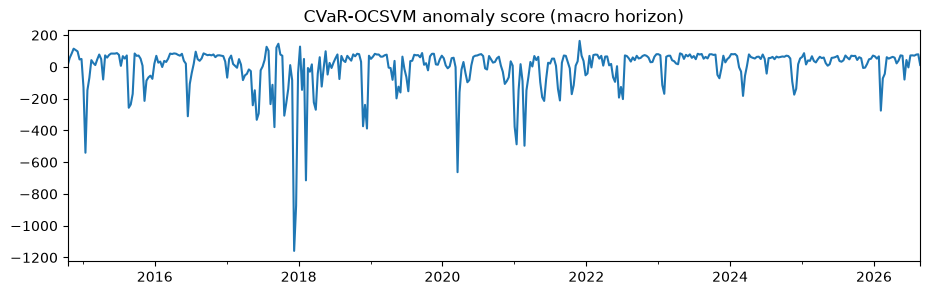

In [4]:
from src.models.cvar_ocsvm import CVaROCSVM
from src.features.signatures import signature

d = len(macro_cfg.channels)
ocsvm_depth = 2
# K (the polynomial-approximation / rho-search range) must cover the actual
# scale of <w, S_N(x)> on this data, not an arbitrary constant -- real BTC
# 30-day-window signatures reach much larger magnitudes than a small
# synthetic Brownian-motion test would. Size it from the training data itself.
train_sigs_depth2 = np.vstack([signature(p, ocsvm_depth) for p in train_paths])
K = 3.0 * np.abs(train_sigs_depth2).max()
print('K set to', K)

cvar_model = CVaROCSVM(ocsvm_depth=ocsvm_depth, d=d, alpha=0.9, K=K, poly_degree=2)
cvar_model.fit(train_paths)
print('converged:', cvar_model.optim_result_.success, 'rho:', cvar_model.rho_, '(K was', K, ')')

cvar_scores = pd.Series(cvar_model.score_many(all_paths), index=pd.DatetimeIndex(all_end_times))
cvar_scores.plot(figsize=(11, 3), title='CVaR-OCSVM anomaly score (macro horizon)')
plt.show()

In [5]:
pd.DataFrame({
    'expected_sig_distance': esd_scores,
    'conformance_score': conf_scores,
    'cvar_ocsvm': cvar_scores,
}).to_parquet('../data/processed/macro_paper_faithful_scores.parquet')